# Task 4: Portfolio Optimization Based on Forecast

This notebook uses Modern Portfolio Theory to construct an optimized portfolio using TSLA, BND, and SPY.

The objective is to:
- Prepare expected returns
- Compute the covariance matrix
- Visualize asset relationships
- Generate the Efficient Frontier
- Identify optimal portfolios
- Recommend a final allocation for GMF

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

In [2]:
start_date = "2015-01-01"
end_date = "2026-06-30"

tickers = ["TSLA", "BND", "SPY"]

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust=False
)

data.head()

Price       Adj Close                             Close              \
Ticker            BND         SPY       TSLA        BND         SPY   
Date                                                                  
2015-01-02  59.405418  169.687851  14.620667  82.650002  205.429993   
2015-01-05  59.577919  166.623337  14.006000  82.889999  201.720001   
2015-01-06  59.750404  165.053955  14.085333  83.129997  199.820007   
2015-01-07  59.786324  167.110641  14.063333  83.180000  202.309998   
2015-01-08  59.692902  170.076111  14.041333  83.050003  205.899994   

Price                       High                               Low  \
Ticker           TSLA        BND         SPY       TSLA        BND   
Date                                                                 
2015-01-02  14.620667  82.690002  206.880005  14.883333  82.419998   
2015-01-05  14.006000  82.919998  204.369995  14.433333  82.699997   
2015-01-06  14.085333  83.379997  202.720001  14.280000  83.029999   
2015-01-07  14.063333  83.279999  202.720001  14.318667  83.050003   
2015-01-08  14.041333  83.110001  206.160004  14.253333  82.970001   

Price                                   Open                          Volume  \
Ticker             SPY       TSLA        BND         SPY       TSLA      BND   
Date                                                                           
2015-01-02  204.179993  14.217333  82.430000  206.380005  14.858000  2218800   
2015-01-05  201.350006  13.810667  82.739998  204.169998  14.303333  5820100   
2015-01-06  198.860001  13.614000  83.029999  202.089996  14.004000  3887600   
2015-01-07  200.880005  13.985333  83.139999  201.419998  14.223333  2433400   
2015-01-08  203.990005  14.000667  83.110001  204.009995  14.187333  1873400   

Price                            
Ticker            SPY      TSLA  
Date                             
2015-01-02  121465900  71466000  
2015-01-05  169632600  80527500  
2015-01-06  209151400  93928500  
2015-01-07  125346700  44526000  
2015-01-08  147217800  51637500

In [3]:
close_prices = data["Close"]

close_prices.head()

Ticker,BND,SPY,TSLA
Date,,,
2015-01-02,82.650002,205.429993,14.620667
2015-01-05,82.889999,201.720001,14.006000
2015-01-06,83.129997,199.820007,14.085333
2015-01-07,83.180000,202.309998,14.063333
2015-01-08,83.050003,205.899994,14.041333


In [4]:
print("Shape:")
print(close_prices.shape)

print("\nMissing Values:")
print(close_prices.isna().sum())

print("\nDuplicate Rows:")
print(close_prices.duplicated().sum())

Shape:
(2888, 3)

Missing Values:
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64

Duplicate Rows:
0


In [5]:
daily_returns = close_prices.pct_change().dropna()

daily_returns.head()

Ticker,BND,SPY,TSLA
Date,,,
2015-01-05,0.002904,-0.018060,-0.042041
2015-01-06,0.002895,-0.009419,0.005664
2015-01-07,0.000602,0.012461,-0.001562
2015-01-08,-0.001563,0.017745,-0.001564
2015-01-09,0.001686,-0.008014,-0.018802


In [6]:
trading_days = 252

expected_annual_returns = daily_returns.mean() * trading_days

expected_annual_returns

Ticker
BND    -0.008548
SPY     0.127746
TSLA    0.454239
dtype: float64

In [7]:
annual_covariance_matrix = daily_returns.cov() * trading_days

annual_covariance_matrix

Ticker,BND,SPY,TSLA
Ticker,,,
BND,0.002883,0.001045,0.001793
SPY,0.001045,0.031402,0.049795
TSLA,0.001793,0.049795,0.326926


In [8]:
correlation_matrix = daily_returns.corr()

correlation_matrix

Ticker,BND,SPY,TSLA
Ticker,,,
BND,1.000000,0.109867,0.058409
SPY,0.109867,1.000000,0.491456
TSLA,0.058409,0.491456,1.000000


<Figure size 800x600 with 0 Axes>

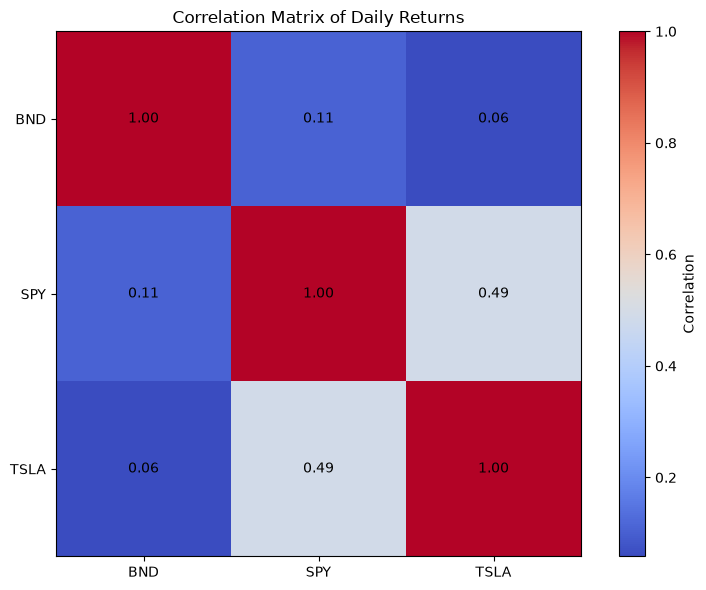

In [16]:
plt.figure(figsize=(8, 6))

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

fig.colorbar(im, ax=ax, label="Correlation")

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))

ax.set_xticklabels(correlation_matrix.columns)
ax.set_yticklabels(correlation_matrix.index)

ax.set_title("Correlation Matrix of Daily Returns")

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

import os
os.makedirs("reports/figures", exist_ok=True)

fig.tight_layout()

fig.savefig(
    "reports/figures/task4_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
import os

os.makedirs("reports/figures", exist_ok=True)

In [12]:
import os

print(os.getcwd())

c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 9\portfolio-optimization\notebooks


## Portfolio Input Interpretation

The expected annual returns provide the return assumptions used for portfolio optimization. TSLA represents the highest-risk growth asset, BND provides defensive bond exposure, and SPY offers diversified equity market exposure.

The covariance matrix captures how asset returns move together and is essential for calculating portfolio risk. The correlation matrix shows the strength of relationships between assets. Lower or negative correlations are useful because they can reduce overall portfolio volatility through diversification.

For GMF, these inputs provide the foundation for constructing portfolios that balance expected return against risk rather than selecting assets based only on historical performance.

In [17]:
from pypfopt import EfficientFrontier
from pypfopt import expected_returns
from pypfopt import risk_models
from pypfopt import plotting

In [18]:
mu = expected_returns.mean_historical_return(close_prices)

mu

Ticker
BND    -0.009943
SPY     0.118492
TSLA    0.338279
dtype: float64

In [19]:
S = risk_models.sample_cov(close_prices)

S

Ticker,BND,SPY,TSLA
Ticker,,,
BND,0.002883,0.001045,0.001793
SPY,0.001045,0.031402,0.049795
TSLA,0.001793,0.049795,0.326926


In [20]:
ef = EfficientFrontier(mu, S)

weights_sharpe = ef.max_sharpe()

cleaned_weights_sharpe = ef.clean_weights()

cleaned_weights_sharpe

OrderedDict([('BND', 0.0), ('SPY', 0.82258), ('TSLA', 0.17742)])

In [21]:
performance_sharpe = ef.portfolio_performance(verbose=True)


Expected annual return: 15.7%
Annual volatility: 21.5%
Sharpe Ratio: 0.73


In [22]:
ef_min = EfficientFrontier(mu, S)

weights_min = ef_min.min_volatility()

cleaned_weights_min = ef_min.clean_weights()

cleaned_weights_min

OrderedDict([('BND', 0.94291), ('SPY', 0.05709), ('TSLA', 0.0)])

In [23]:
performance_min = ef_min.portfolio_performance(verbose=True)

Expected annual return: -0.3%
Annual volatility: 5.3%
Sharpe Ratio: -0.05


In [24]:
weights_df = pd.DataFrame({
    "Maximum Sharpe": cleaned_weights_sharpe,
    "Minimum Volatility": cleaned_weights_min
})

weights_df

,Maximum Sharpe,Minimum Volatility
BND,0.00000,0.94291
SPY,0.82258,0.05709
TSLA,0.17742,0.00000


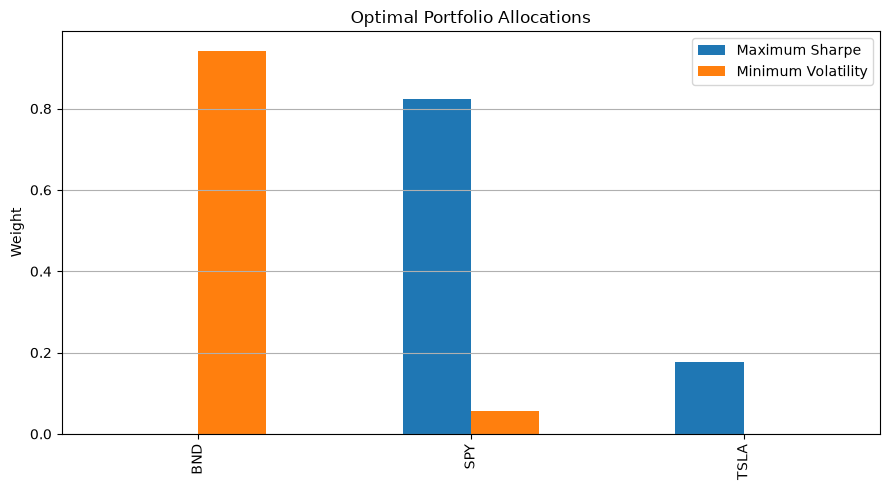

In [25]:
fig, ax = plt.subplots(figsize=(9,5))

weights_df.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Optimal Portfolio Allocations")

ax.set_ylabel("Weight")

ax.grid(axis="y")

import os
os.makedirs("reports/figures", exist_ok=True)

fig.tight_layout()

fig.savefig(
    "reports/figures/task4_portfolio_weights.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

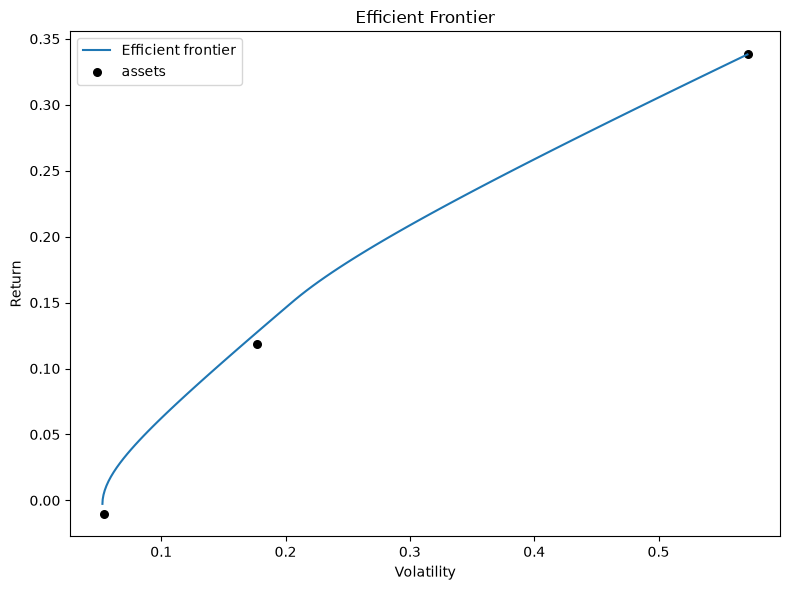

In [26]:
fig, ax = plt.subplots(figsize=(8,6))

plotting.plot_efficient_frontier(
    EfficientFrontier(mu, S),
    ax=ax,
    show_assets=True
)

ax.set_title("Efficient Frontier")

fig.tight_layout()

fig.savefig(
    "reports/figures/task4_efficient_frontier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Portfolio Optimization Interpretation

Modern Portfolio Theory identifies asset allocations that maximize expected return for a given level of risk.

The Maximum Sharpe portfolio seeks the highest risk-adjusted return by balancing expected return and portfolio volatility. In contrast, the Minimum Volatility portfolio prioritizes risk reduction, making it suitable for conservative investors.

The Efficient Frontier illustrates the set of optimal portfolios that provide the highest expected return for each level of portfolio risk. Portfolios located below the frontier are considered inefficient because they offer lower expected returns for the same level of risk.

For Guide Me in Finance (GMF), these optimized allocations provide a quantitative basis for constructing diversified investment portfolios that align with different client risk preferences and investment objectives.